<a href="https://colab.research.google.com/github/gregoirehendrix/Master_Thesis/blob/main/piping_losses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Amount of CSP units per power block : 100
Maximal amount of units per group   : 5


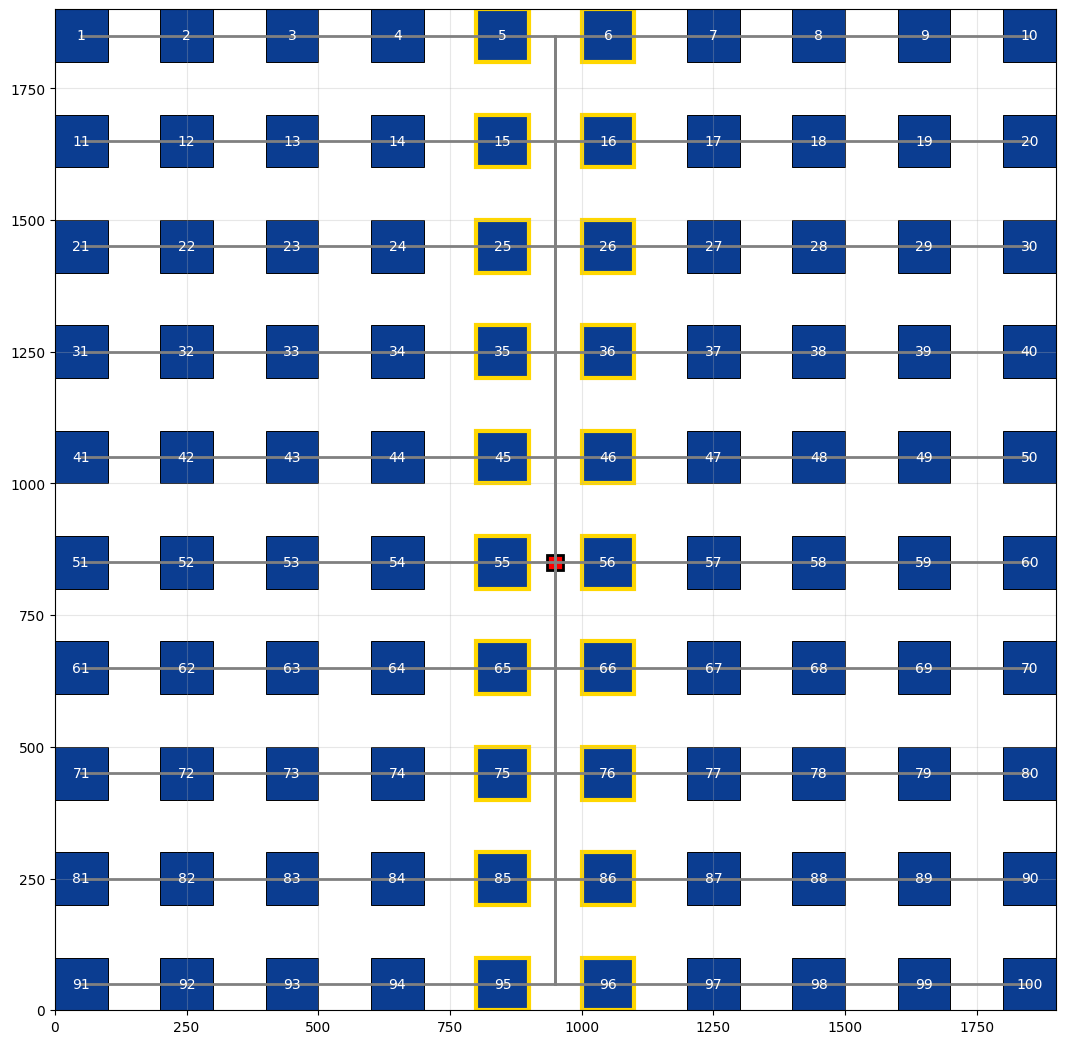

Total piping length          : 28000.0 m
Average piping length/unit   : 280.0 m
RMS piping length per branch : 349.28498393145964 m

=== Groupings ===
Hub 5 → [1, 2, 3, 4, 5]
Hub 6 → [6, 7, 8, 9, 10]
Hub 15 → [11, 12, 13, 14, 15]
Hub 16 → [16, 17, 18, 19, 20]
Hub 25 → [21, 22, 23, 24, 25]
Hub 26 → [26, 27, 28, 29, 30]
Hub 35 → [31, 32, 33, 34, 35]
Hub 36 → [36, 37, 38, 39, 40]
Hub 45 → [41, 42, 43, 44, 45]
Hub 46 → [46, 47, 48, 49, 50]
Hub 55 → [51, 52, 53, 54, 55]
Hub 56 → [56, 57, 58, 59, 60]
Hub 65 → [61, 62, 63, 64, 65]
Hub 66 → [66, 67, 68, 69, 70]
Hub 75 → [71, 72, 73, 74, 75]
Hub 76 → [76, 77, 78, 79, 80]
Hub 85 → [81, 82, 83, 84, 85]
Hub 86 → [86, 87, 88, 89, 90]
Hub 95 → [91, 92, 93, 94, 95]
Hub 96 → [96, 97, 98, 99, 100]

=== Total length per diameter ===
  3" : 16000.00 m
  2 1/2" : 4000.00 m
  2" : 4000.00 m
  1 1/4" : 4000.00 m

=== Pipe lengths per hub ===

Hub 5 :
  1 1/4" : 200.00 m
  2 1/2" : 200.00 m
  2" : 200.00 m
  3" : 1300.00 m

Hub 6 :
  1 1/4" : 200.00 m
  2 1/

In [ ]:
# -*- coding: utf-8 -*-
"""
CSP Field Piping Network — Layout Optimiser + Cascaded Thermal Loss Model
Author: Grégoire Hendrix
Date  : Apr 2026

Layout  : symmetric diamond grid, power block at centroid interstice
Thermal : Bicouche cylindrical resistance model (silica aerogel + rockwool),
          cascaded from leaves to PB with adiabatic mixing at every junction node
"""

import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


# =============================================================================
# 1.  LAYOUT OPTIMISER
# =============================================================================

class CSPOptimizerRows:
    def __init__(self, DIST, CAP):
        self.DIST = DIST
        self.CAP  = CAP

    def coord(self, p):
        i, j = p
        return (j * self.DIST, i * self.DIST)

    def manhattan(self, a, b):
        return abs(a[0] - b[0]) + abs(a[1] - b[1])

    def generate_blue_towers(self, nb):
        n_side    = math.ceil(math.sqrt(nb))
        M         = n_side * 2 - 1
        positions = [(i, j) for i in range(0, M, 2)
                             for j in range(0, M, 2)]
        L  = (M - 1) * self.DIST
        cx, cy = L / 2, L / 2
        coords = np.array([self.coord(p) for p in positions])
        dist_c = np.sqrt((coords[:, 0] - cx)**2 + (coords[:, 1] - cy)**2)
        sel    = np.argsort(dist_c)[:nb]
        return [positions[i] for i in sel], M

    def group_by_rows(self, blue_pos):
        ordered = sorted(
            list(enumerate(blue_pos, start=1)),
            key=lambda x: (x[1][0], x[1][1])
        )
        clusters, row, buffer = [], None, []
        for idx, pos in ordered:
            r, c = pos
            if row is None:
                row = r
            if r != row:
                for k in range(0, len(buffer), self.CAP):
                    clusters.append(buffer[k:k + self.CAP])
                buffer, row = [], r
            buffer.append(idx)
        for k in range(0, len(buffer), self.CAP):
            clusters.append(buffer[k:k + self.CAP])
        return clusters

    def mst_with_hub(self, nodes, coords, hub):
        if len(nodes) == 1:
            return {}
        visited, unvisited, parent = {hub}, set(n for n in nodes if n != hub), {}
        while unvisited:
            best, best_d = None, math.inf
            for u in visited:
                for v in unvisited:
                    d = self.manhattan(coords[u], coords[v])
                    if d < best_d:
                        best_d, best = d, (u, v)
            u, v = best
            parent[v] = u
            visited.add(v)
            unvisited.remove(v)
        return parent

    def build_network_for_pb(self, blue_pos, clusters, pb):
        coords    = {0: self.coord(pb)}
        coords.update({i: self.coord(blue_pos[i - 1])
                       for i in range(1, len(blue_pos) + 1)})
        pb_coord  = coords[0]
        parent, cluster_map = {}, {}
        for cluster in clusters:
            hub = min(cluster, key=lambda i: self.manhattan(coords[i], pb_coord))
            for v, u in self.mst_with_hub(cluster, coords, hub).items():
                parent[v] = u
            parent[hub]      = 0
            cluster_map[hub] = cluster
        total = sum(self.manhattan(coords[b], coords[p]) for b, p in parent.items())
        return parent, coords, cluster_map, total

    def find_best_pb(self, blue_pos, M):
        clusters = self.group_by_rows(blue_pos)
        blue_set = set(blue_pos)
        candidates = [(i, j) for i in range(M) for j in range(M)
                      if (i, j) not in blue_set]
        best = None
        for pb in candidates:
            parent, coords, info, cost = self.build_network_for_pb(
                blue_pos, clusters, pb)
            if best is None or cost < best["cost"]:
                best = dict(pb=pb, parent=parent, coords=coords,
                            clusters=info, cost=cost)
        return best


# =============================================================================
# 2.  PIPE CHARGES & DIAMETERS
# =============================================================================

DIAM_TABLE = {
    1: '1 1/4"',
    2: '2"',
    3: '2 1/2"',
    4: '3"',
    5: '3"'
}

# External pipe diameters [m] — from supplier data (Excel colleague)
DIAMETER_M = {
    '1 1/4"': 0.0422,   # DN32
    '2"'    : 0.0603,   # DN50
    '2 1/2"': 0.0730,   # DN65
    '3"'    : 0.0889,   # DN80
}


def compute_pipe_charges_and_diameters(parent, nb_units, diameter_table):
    children = {i: [] for i in range(nb_units + 1)}
    for child, par in parent.items():
        children[par].append(child)

    charge = {}

    def dfs(node):
        if node != 0 and not children[node]:
            charge[node] = 1
            return 1
        total = 1 if node != 0 else 0
        for ch in children[node]:
            total += dfs(ch)
        charge[node] = total
        return total

    dfs(0)

    pipe_info = {}
    for b, p in parent.items():
        c    = charge[b]
        diam = diameter_table.get(c, diameter_table[max(diameter_table)])
        pipe_info[(b, p)] = dict(charge=c, diameter=diam)

    return pipe_info, charge, children


def compute_length_per_diameter(parent, coords, pipe_info):
    length_per_diam = {}
    for (child, par), info in pipe_info.items():
        diam = info["diameter"]
        x1, y1 = coords[child]
        x2, y2 = coords[par]
        dist   = abs(x1 - x2) + abs(y1 - y2)
        length_per_diam[diam] = length_per_diam.get(diam, 0) + dist
    return length_per_diam


# =============================================================================
# 3.  BICOUCHE CYLINDRICAL THERMAL RESISTANCE MODEL
# =============================================================================

# -----------------------------------------------------------------------------
# INSULATION MODE — choose one:
#   "silica+rockwool"  : silica aerogel inner layer + rockwool outer layer
#   "rockwool_only"    : rockwool only, same total thickness
# -----------------------------------------------------------------------------
INSULATION_MODE = "rockwool_only"

# Total insulation thickness [m] — kept constant between modes for fair comparison
E_INSULATION_TOTAL = 0.12   # m

# Per-layer thicknesses (only used in "silica+rockwool" mode)
E_SILICA   = 0.020          # m — silica aerogel inner layer
E_ROCKWOOL = E_INSULATION_TOTAL - E_SILICA   # m — rockwool outer layer (0.080 m)

# Thermal conductivities [W/m·K] — ambient temperature values (conservative)
# At 565°C: λ_silica ≈ 0.035–0.050, λ_rockwool ≈ 0.10–0.15 W/m·K  → losses underestimated ~2–3×
LAMBDA_SILICA   = 0.017
LAMBDA_ROCKWOOL = 0.040

H_EXT = 10.0   # W/m²·K — natural external convection (estimate)


def _resolve_insulation(D_ext_pipe):
    """
    Return (e_silica, e_rockwool, lambda_silica, lambda_rockwool)
    according to INSULATION_MODE.
    Total insulation thickness is always E_INSULATION_TOTAL.
    """
    if INSULATION_MODE == "silica+rockwool":
        return E_SILICA, E_ROCKWOOL, LAMBDA_SILICA, LAMBDA_ROCKWOOL
    elif INSULATION_MODE == "rockwool_only":
        # Single rockwool layer — modelled as silica layer of zero thickness
        # i.e. e_silica=0 → D2=D1, R_silica=0
        return 0.0, E_INSULATION_TOTAL, LAMBDA_SILICA, LAMBDA_ROCKWOOL
    else:
        raise ValueError(f"Unknown INSULATION_MODE: '{INSULATION_MODE}'. "
                         f"Choose 'silica+rockwool' or 'rockwool_only'.")


def compute_U_and_Dtotal(D_ext_pipe, e_silica, e_rockwool,
                          lambda_silica, lambda_rockwool, h_ext):
    """
    Cylindrical thermal resistance per unit length [K·m/W].
    Works for both single-layer (e_silica=0) and bicouche configurations.

    Geometry:
        D1 = D_ext_pipe
        D2 = D1 + 2*e_silica      (= D1 if rockwool_only)
        D3 = D2 + 2*e_rockwool    (outer insulation surface)

    R_total = R_silica + R_rockwool + R_conv_ext

    Returns U_eq [W/m²·K] referenced to D_ext_pipe, and D_total [m].
    """
    D1 = D_ext_pipe
    D2 = D1 + 2 * e_silica
    D3 = D2 + 2 * e_rockwool

    R_silica   = math.log(D2 / D1) / (2 * math.pi * lambda_silica) if e_silica > 0 else 0.0
    R_rockwool = math.log(D3 / D2) / (2 * math.pi * lambda_rockwool)
    R_conv     = 1.0 / (h_ext * math.pi * D3)

    R_total = R_silica + R_rockwool + R_conv   # K·m/W
    U_eq    = 1.0 / (R_total * math.pi * D1)  # W/m²·K
    return U_eq, D3


def pipe_heat_loss(T_in, T_amb, m_dot, Cp, D_ext_pipe, L,
                   e_silica, e_rockwool,
                   lambda_silica, lambda_rockwool, h_ext,
                   _mode_override=None):
    """
    NTU model with bicouche U_eq.
    Cp evaluated at mean temperature between T_in and a first-guess T_out.

    Returns T_out [K], Q_loss [W], U_eq [W/m²·K], NTU [-].
    """
    U_eq, D_total = compute_U_and_Dtotal(
        D_ext_pipe, e_silica, e_rockwool,
        lambda_silica, lambda_rockwool, h_ext)

    # --- Cp at mean temperature (one iteration) ---
    A        = math.pi * D_ext_pipe * L
    NTU_0    = U_eq * A / (m_dot * Cp)
    T_out_0  = T_amb + (T_in - T_amb) * math.exp(-NTU_0)
    T_mean   = (T_in + T_out_0) / 2
    Cp_mean  = 1443.0 + 0.172 * (T_mean - 273.15)

    NTU   = U_eq * A / (m_dot * Cp_mean)
    T_out = T_amb + (T_in - T_amb) * math.exp(-NTU)
    Q_loss = m_dot * Cp_mean * (T_in - T_out)

    return T_out, Q_loss, U_eq, NTU, D_total


# =============================================================================
# 4.  CASCADED THERMAL MODEL
# =============================================================================

def compute_cascaded_temperatures(
        parent, coords, pipe_info, children,
        T_hot, T_amb, m_dot_unit, Cp_salt,
        DIAMETER_M, h_ext):
    """
    Post-order DFS from leaves to PB.

    At each leaf   : T_in = T_hot (solar field outlet)
    At each node   : adiabatic mix of all incoming flows → T_in for next segment
    Cp updated at mean temperature of each segment.

    Returns
    -------
    node_T_out   : dict  node_id → mixed temperature at that node [K]
    pipe_results : dict  (child, parent) → {T_in, T_out, m_dot, L, diam,
                                             D_total, U_eq, NTU, Q_loss}
    T_PB         : float  mixed temperature entering the power block [K]
    """
    node_T_out   = {}
    pipe_results = {}

    def _segment(child, par, T_ch):
        m_ch   = pipe_info[(child, par)]["charge"] * m_dot_unit
        diam   = pipe_info[(child, par)]["diameter"]
        D_k    = DIAMETER_M[diam]
        x1, y1 = coords[child]
        x2, y2 = coords[par]
        L_k    = abs(x1 - x2) + abs(y1 - y2)

        Cp_in = 1443.0 + 0.172 * (T_ch - 273.15)

        e_s, e_r, ls, lr = _resolve_insulation(D_k)

        T_out_k, Q_loss_k, U_k, NTU_k, D_total_k = pipe_heat_loss(
            T_ch, T_amb, m_ch, Cp_in, D_k, L_k,
            e_s, e_r, ls, lr, h_ext)

        pipe_results[(child, par)] = dict(
            T_in    = T_ch,
            T_out   = T_out_k,
            m_dot   = m_ch,
            L       = L_k,
            diam    = diam,
            D_total = D_total_k,
            U_eq    = U_k,
            NTU     = NTU_k,
            Q_loss  = Q_loss_k,
        )
        return T_out_k, m_ch

    def dfs(node):
        if node != 0 and not children[node]:
            node_T_out[node] = T_hot
            return

        for ch in children[node]:
            dfs(ch)

        if node == 0:
            return

        # Adiabatic mix of incoming segments
        m_total = 0.0
        H_total = 0.0
        for ch in children[node]:
            T_out_k, m_ch = _segment(ch, node, node_T_out[ch])
            Cp_out = 1443.0 + 0.172 * (T_out_k - 273.15)
            m_total += m_ch
            H_total += m_ch * Cp_out * T_out_k

        # weighted enthalpy mix
        Cp_mix        = 1443.0 + 0.172 * ((H_total / m_total) / (
            sum((pipe_info[(ch, node)]["charge"] * m_dot_unit) *
                (1443.0 + 0.172 * (pipe_results[(ch, node)]["T_out"] - 273.15))
                for ch in children[node])) - 273.15) if m_total > 0 else Cp_salt
        # simpler: mass-flow-weighted T (Cp nearly constant over small ΔT)
        T_mix = sum(
            pipe_info[(ch, node)]["charge"] * m_dot_unit *
            pipe_results[(ch, node)]["T_out"]
            for ch in children[node]
        ) / m_total
        node_T_out[node] = T_mix

    for ch in children[0]:
        dfs(ch)

    # Final segments: hubs → PB
    m_pb_total = 0.0
    H_pb_total = 0.0
    for ch in children[0]:
        T_out_k, m_ch = _segment(ch, 0, node_T_out[ch])
        Cp_out = 1443.0 + 0.172 * (T_out_k - 273.15)
        m_pb_total += m_ch
        H_pb_total += m_ch * Cp_out * T_out_k

    # mass-flow-weighted mix at PB
    T_PB = sum(
        pipe_info[(ch, 0)]["charge"] * m_dot_unit *
        pipe_results[(ch, 0)]["T_out"]
        for ch in children[0]
    ) / m_pb_total

    return node_T_out, pipe_results, T_PB


# =============================================================================
# 5.  REPORTING
# =============================================================================

def print_thermal_results(pipe_results, internal_to_visual, children, nb):
    hubs = set(children[0])

    member_to_hub = {}
    for hub in hubs:
        for m in _all_descendants(hub, children):
            member_to_hub[m] = hub
        member_to_hub[hub] = hub

    hub_pipes = {h: [] for h in hubs}
    for (child, par), info in pipe_results.items():
        h = member_to_hub.get(child)
        if h is not None:
            hub_pipes[h].append((child, par, info))

    print("\n=== Per-hub cascaded thermal results ===")
    total_Q = 0.0

    hub_vis_list = sorted(hubs, key=lambda h: internal_to_visual[h])
    for hub in hub_vis_list:
        hub_vis = internal_to_visual[hub]
        print(f"\n--- Hub {hub_vis} ---")
        pipes = sorted(hub_pipes[hub],
                       key=lambda x: internal_to_visual.get(x[0], 0))
        hub_Q = 0.0
        for child, par, info in pipes:
            c_vis = internal_to_visual.get(child, "PB")
            p_vis = internal_to_visual.get(par,   "PB") if par != 0 else "PB"
            q_flux  = info['Q_loss'] / (math.pi * info['D_total'] * info['L'])
            print(f"  [{c_vis} → {p_vis}]  "
                  f"diam={info['diam']:8s}  "
                  f"D_tot={info['D_total']*1e3:5.1f}mm  "
                  f"L={info['L']:6.1f}m  "
                  f"ṁ={info['m_dot']:5.2f}kg/s  "
                  f"U={info['U_eq']:.4f}W/m²K  "
                  f"T_in={info['T_in']-273.15:6.2f}°C  "
                  f"T_out={info['T_out']-273.15:6.2f}°C  "
                  f"Q={info['Q_loss']/1e3:6.3f}kW"
                  f"q={q_flux:.1f}W/m²")
            hub_Q += info['Q_loss']
        total_Q += hub_Q
        print(f"  → Hub total loss : {hub_Q/1e3:.3f} kW")

    print(f"\n>>> TOTAL piping losses : {total_Q/1e6:.4f} MW")
    return total_Q


def _all_descendants(node, children):
    result = [node]
    for ch in children[node]:
        result.extend(_all_descendants(ch, children))
    return result


def compute_hub_pipe_details(parent, coords, pipe_info, clusters, nb_units):
    member_to_hub = {}
    for hub, members in clusters.items():
        for m in members:
            member_to_hub[m] = hub
    hub_pipes = {hub: {} for hub in clusters}
    for (child, par), info in pipe_info.items():
        diam = info["diameter"]
        x1, y1 = coords[child]
        x2, y2 = coords[par]
        dist   = abs(x1 - x2) + abs(y1 - y2)
        hub    = child if par == 0 else member_to_hub.get(child)
        if hub is not None and hub in hub_pipes:
            hub_pipes[hub][diam] = hub_pipes[hub].get(diam, 0) + dist
    return hub_pipes


def print_hub_pipe_details(hub_pipes, internal_to_visual):
    print("\n=== Pipe lengths per hub ===")
    result = [(internal_to_visual[h], d) for h, d in hub_pipes.items()]
    for hub_vis, diam_dict in sorted(result):
        print(f"\nHub {hub_vis} :")
        for diam, L in sorted(diam_dict.items()):
            print(f"  {diam} : {L:.2f} m")


def print_insulation_summary():
    """Print U_eq and D_total for each pipe diameter — useful for validation."""
    print(f"\n=== Insulation model summary  [mode: {INSULATION_MODE}] ===")
    print(f"  Total insulation thickness : {E_INSULATION_TOTAL*1e3:.0f} mm")
    if INSULATION_MODE == "silica+rockwool":
        print(f"  Silica aerogel : e={E_SILICA*1e3:.0f}mm,  λ={LAMBDA_SILICA:.3f} W/m·K")
        print(f"  Rockwool       : e={(E_INSULATION_TOTAL-E_SILICA)*1e3:.0f}mm,  λ={LAMBDA_ROCKWOOL:.3f} W/m·K")
    else:
        print(f"  Rockwool only  : e={E_INSULATION_TOTAL*1e3:.0f}mm,  λ={LAMBDA_ROCKWOOL:.3f} W/m·K")
    print(f"  h_ext          : {H_EXT:.1f} W/m²·K")
    print(f"  {'Diam':10s}  {'D_ext[mm]':10s}  {'D_total[mm]':12s}  {'U_eq[W/m²K]':12s}")
    for diam, D_ext in DIAMETER_M.items():
        e_s, e_r, ls, lr = _resolve_insulation(D_ext)
        U_eq, D_total = compute_U_and_Dtotal(D_ext, e_s, e_r, ls, lr, H_EXT)
        print(f"  {diam:10s}  {D_ext*1e3:10.1f}  {D_total*1e3:12.1f}  {U_eq:12.4f}")


# =============================================================================
# 6.  VISUALISATION
# =============================================================================

def make_visual_mapping(blue_pos):
    blue_for_display = sorted(
        [(i, pos) for i, pos in enumerate(blue_pos, start=1)],
        key=lambda x: (-x[1][0], x[1][1])
    )
    internal_to_visual = {
        internal: display
        for display, (internal, _) in enumerate(blue_for_display, start=1)
    }
    return blue_for_display, internal_to_visual


def plot_network(blue_pos, sol, DIST, M):
    parent   = sol["parent"]
    coords   = sol["coords"]
    clusters = sol["clusters"]
    hubs     = set(clusters.keys())

    fig, ax = plt.subplots(figsize=(13, 13))
    ax.set_aspect("equal")

    blue_for_display, internal_to_visual = make_visual_mapping(blue_pos)

    for display_id, (internal_id, (r, c)) in enumerate(blue_for_display, start=1):
        x, y = c * DIST, r * DIST
        edge = "#FFD700" if internal_id in hubs else "black"
        lw   = 3         if internal_id in hubs else 0.7
        ax.add_patch(Rectangle((x, y), DIST, DIST,
                               facecolor="#0B3D91", edgecolor=edge, linewidth=lw))
        ax.text(x + DIST / 2, y + DIST / 2, str(display_id),
                ha="center", va="center", color="white")

    PB_SIZE = 0.3 * DIST
    xpb, ypb = coords[0]
    ax.add_patch(Rectangle(
        (xpb + (DIST - PB_SIZE) / 2, ypb + (DIST - PB_SIZE) / 2),
        PB_SIZE, PB_SIZE, facecolor="red", edgecolor="black", linewidth=2))

    for b, p in parent.items():
        bx, by = coords[b][0] + DIST / 2, coords[b][1] + DIST / 2
        px, py = coords[p][0] + DIST / 2, coords[p][1] + DIST / 2
        ax.plot([bx, px], [by, by], color="gray", linewidth=2)
        ax.plot([px, px], [by, py], color="gray", linewidth=2)

    ax.set_xlim(0, M * DIST)
    ax.set_ylim(0, M * DIST)
    ax.grid(True, alpha=0.3)
    plt.show()
    return internal_to_visual


def print_clusters_visual(clusters, mapping):
    print("\n=== Groupings ===")
    result = []
    for hub_int, members_int in clusters.items():
        hub_vis     = mapping[hub_int]
        members_vis = [mapping[m] for m in members_int]
        result.append((hub_vis, sorted(members_vis)))
    for hub, members in sorted(result):
        print(f"Hub {hub} → {members}")


# =============================================================================
# 7.  MAIN
# =============================================================================

if __name__ == "__main__":

    # --- Inputs ---
    nb     = int(input("Amount of CSP units per power block : "))
    CAP    = int(input("Maximal amount of units per group   : "))
    DIST_2 = 200          # centre-to-centre distance [m]
    DIST   = DIST_2 / 2

    # --- Thermal parameters ---
    T_hot      = 565 + 273.15    # K
    T_amb      =  25 + 273.15    # K
    T_C        = T_hot - 273.15
    Cp_salt    = 1443.0 + 0.172 * T_C   # J/kg·K  (evaluated at T_hot; updated per segment)
    m_dot_unit = 5.99 #6.39             # kg/s per CSP unit

    # --- Layout optimisation ---
    opt         = CSPOptimizerRows(DIST, CAP)
    blue_pos, M = opt.generate_blue_towers(nb)
    sol         = opt.find_best_pb(blue_pos, M)

    # --- Pipe charges, diameters ---
    pipe_info, charge, children = compute_pipe_charges_and_diameters(
        sol["parent"], nb, DIAM_TABLE)

    # --- Layout metrics ---
    branch_lengths = [
        abs(sol["coords"][b][0] - sol["coords"][p][0]) +
        abs(sol["coords"][b][1] - sol["coords"][p][1])
        for b, p in sol["parent"].items()
    ]
    rms = math.sqrt(sum(L**2 for L in branch_lengths) / len(branch_lengths))

    # --- Plot ---
    mapping = plot_network(blue_pos, sol, DIST, M)

    # --- Layout summary ---
    print("Total piping length          :", sol["cost"], "m")
    print("Average piping length/unit   :", sol["cost"] / nb, "m")
    print("RMS piping length per branch :", rms, "m")

    print_clusters_visual(sol["clusters"], mapping)

    lengths = compute_length_per_diameter(sol["parent"], sol["coords"], pipe_info)
    print("\n=== Total length per diameter ===")
    for diam, L in lengths.items():
        print(f"  {diam} : {L:.2f} m")

    print_hub_pipe_details(
        compute_hub_pipe_details(sol["parent"], sol["coords"],
                                 pipe_info, sol["clusters"], nb),
        mapping)

    # --- Insulation model summary ---
    print_insulation_summary()

    # --- Cascaded thermal model ---
    node_T_out, pipe_results, T_PB = compute_cascaded_temperatures(
        parent     = sol["parent"],
        coords     = sol["coords"],
        pipe_info  = pipe_info,
        children   = children,
        T_hot      = T_hot,
        T_amb      = T_amb,
        m_dot_unit = m_dot_unit,
        Cp_salt    = Cp_salt,
        DIAMETER_M = DIAMETER_M,
        h_ext      = H_EXT,
    )

    total_Q = print_thermal_results(pipe_results, mapping, children, nb)

    print(f"\n>>> Salt temperature at PB inlet : {T_PB - 273.15:.3f} °C")
    print(f"    (drop vs solar field outlet  : {T_hot - T_PB:.3f} K)")
    print(f"    Total thermal losses         : {total_Q/1e6:.4f} MW")